In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_ellipse(x, P, ax=None, n_std=2.0,  **kwargs):
        """
        Plots the expected value and uncertainty ellipse of a bivariate normal distribution
        
        :param x: Expected value 
        :param P: Covariance matrix
        :param ax: Matplotlib Axes object to plot on. If None, uses plt.gca().
        :param n_std: Number of standard deviations for the uncertainty ellipse. 
                      Defaults to 2.0 (approx 86% confidence interval in 2D).
        :param kwargs: Additional keyword arguments passed to the Ellipse patch 
                       (e.g., color, alpha, label).
        :return: The Matplotlib Axes object.
        """ 
        
        # Sanitize inputs
        x = np.asarray(x, dtype=float)
        if x.size != 2:
            raise ValueError(f"State vector x must have exactly 2 elements, got {x.size}")
        x=x.ravel()
        
        P = np.asarray(P, dtype=float)
        if P.size !=4:
            raise ValueError   
        P=P.reshape((2,2))
        
        if ax is None:
             ax = plt.gca()

        # 1. Calculate eigenvalues and eigenvectors
        eigvals, eigvecs = np.linalg.eigh(P)
        
        # Safeguard against numerical precision issues causing slightly negative eigenvalues
        eigvals = np.maximum(eigvals, 0)
        
        # Sort eigenvalues in descending order to identify major and minor axes
        order = eigvals.argsort()[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]
        
        # 2. Calculate ellipse parameters
        angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
        width, height = 2 * n_std * np.sqrt(eigvals)
        
        # Default styling for the ellipse
        ellipse_style = {'alpha': 0.3, 'color': 'blue'}
        ellipse_style.update(kwargs)
        
        # 3. Create and add the ellipse patch
        ell = Ellipse(xy=(x[0], x[1]), 
                      width=width, 
                      height=height, 
                      angle=angle, 
                      **ellipse_style)
        ax.add_patch(ell)
        
        # 4. Plot the expected value as a cross
        marker_color = ellipse_style.get('edgecolor', ellipse_style.get('color', 'blue'))
        ax.plot(x[0], x[1], marker='+', color=marker_color, markersize=8)
        
        return ax
def plot_bar(z_val, std_dev, ax=None, idx=0, n_std=2.0, **kwargs):
    """
    Plots a 1D measurement and its uncertainty as a shaded band across the plot.
    
    This visually represents infinite uncertainty in the unmeasured dimension.
    
    :param z_val: The expected value (scalar) of the measurement.
    :param std_dev: The standard deviation (scalar) of the measurement noise.
    :param ax: Matplotlib Axes object to plot on. If None, uses plt.gca().
    :param idx: The axis index of the measurement. 
                0 means the measurement is on the x-axis (draws a vertical band).
                1 means the measurement is on the y-axis (draws a horizontal band).
    :param n_std: Number of standard deviations for the uncertainty band. Defaults to 2.0.
    :param kwargs: Additional keyword arguments for styling (e.g., color, alpha, label).
    :return: The Matplotlib Axes object.
    """
    # 1. Fallback to current axis if none is provided
    if ax is None:
        ax = plt.gca()

    # 2. Setup default styling, overridden by user-provided kwargs
    bar_style = {'alpha': 0.3, 'color': 'red'}
    bar_style.update(kwargs)    
    
    # Extract line color (defaulting to the same color as the band)
    line_color = bar_style.get('edgecolor', bar_style.get('color', 'red'))

    # 3. Draw the appropriate band based on which axis is being measured
    if idx == 0:
        # Measurement corresponds to the X-axis (Vertical Band)
        ax.axvspan(xmin=z_val - n_std * std_dev, 
                   xmax=z_val + n_std * std_dev, 
                   **bar_style)
        ax.axvline(x=z_val, color=line_color, linestyle='--')
        
    elif idx == 1:
        # Measurement corresponds to the Y-axis (Horizontal Band)
        ax.axhspan(ymin=z_val - n_std * std_dev, 
                   ymax=z_val + n_std * std_dev, 
                   **bar_style)
        ax.axhline(y=z_val, color=line_color, linestyle='--')
        
    else:
        raise ValueError("idx must be 0 (x-axis measurement) or 1 (y-axis measurement)")

    return ax

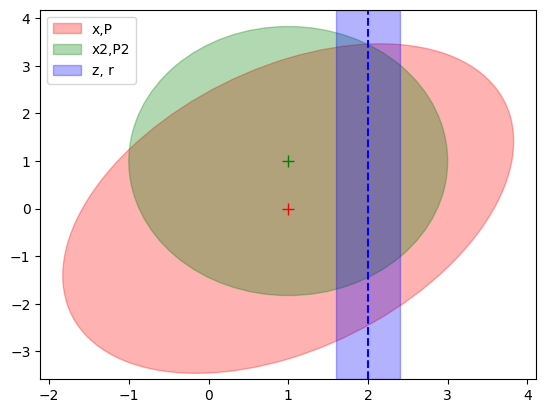

In [3]:
##  Eksempel på bruk:


x=np.array([1,0])
P=np.array([[2,1], [1, 3]])

x2=np.array([1,1])
P2=np.array([[1,0], [0, 2]])

z= 2
r=0.2
fig, ax= plt.subplots()

plot_ellipse(x,P, ax=ax, color='red', label='x,P')
plot_ellipse(x2,P2, ax=ax, color='green', label='x2,P2')
plot_bar(z, r, ax=ax, color='blue', label='z, r')
ax.legend()



# Øving 7: Implementer Kalman-filter

Vi bruker tilstanden $ \mathbf{x}=\begin{bmatrix} p\\ v \end{bmatrix}$

Oppdateringen er 
$$
\begin{aligned}
p_{new} &= p+ \Delta t \cdot v\\
v_{new} &= v+ \sqrt{\Delta t} \sqrt{q}u
\end{aligned}
$$
Der $u$ er en tilfeldig $\mathcal{N}(0,1)$-fordelt variabel.
På matriseform
$$
\mathbf{x}_{new} = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}\mathbf{x} +  \sqrt{\Delta t}\begin{bmatrix} 0 \\ \sqrt{q} \end{bmatrix} u
$$

Transisjonsmatrise: $\Phi=  I+\Delta t F= \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}$

Prosesstøy kovariansmatrise: $Q= \Delta t GG^T=\begin{bmatrix} 0 & 0 \\ 0 & q\Delta t \end{bmatrix}$

I koden skriver vi `x` for $\hat{\mathbf{x}}$.

In [ ]:
# Definer matrisene Phi og Q
dt=1
q=10

Phi=...
Q=...


In [ ]:
### definer startverdier

x=np.array([0, 0])
P=np.array([[1000,0],[0, 1000]])



Prediksjonsformlene er 
$$\begin{aligned}
\hat{\mathbf{x}}_{pred}&= \Phi\hat{\mathbf{x}}\\
P_{pred}&= \Phi P\Phi^T+Q
\end{aligned}
$$

In [ ]:
# Skriv prediksjonsverdiene
x_pred=...
P_pred=...

In [ ]:
# plotter opprinnelig og predikert fordeling.

fig, ax=plt.subplots()
plot_ellipse(x,P, ax=ax, color='purple', label='initial')
plot_ellipse(x_pred,P_pred, ax=ax, color='blue', label='prediksjon')
ax.legend()

Vi får en måling $z$, som er en unøyaktig måling av posisjonen.
$$z=H\mathbf{x}_{new}+w$$
Hvor $H=\begin{bmatrix} 1 && 0 \end{bmatrix}$ og $w$ er målestøy som er  $\mathcal{N}(0, r^2)$-fordelt.

Observasjonsmatrise:  $H=\begin{bmatrix} 1 && 0 \end{bmatrix}$

Målestøy kovariansmatrise: $R=\begin{bmatrix} r^2 \end{bmatrix}$

Vi antar $r=5$.

Forventningen og kovarians gitt målingen beregnes fra Kalman-formlene (Merk: i vårt tilfelle er $\mathbf{y}, \mathbf{z}$ og $S$ skalarer, men det er like greit å implementere med vektorer/matriser med en gang)

$$
\begin{aligned}
\mathbf{y}& = \mathbf{z}-H\hat{\mathbf{x}}_{pred}  && \text{Innovasjon}\\
S&=HP_{pred}H^T+R && \text{Innovasjonsmatrise}\\
K&= P_{pred}H^TS^{-1} && \text{Kalman gain}\\
\hat{\mathbf{x}}_{post}&= \hat{\mathbf{x}}_{pred}+K\mathbf{y} && \text{Posterior forventning}\\
P_{post} &= (I-KH)P_{pred} && \text{Posterior kovarians}
\end{aligned}
$$
*merk*: du kan bruke `np.linalg.inv(S)` for å invertere en matrise.

In [ ]:
r=5
# Definer H og R
H=...
R=...

# Måling
z=np.array([22])
# Implementer Kalman-formlene
y=...
S=...
K=...
x_post=...
P_post=...

In [ ]:
# plotter prediksjon mot posterior

fig, ax= plt.subplots()
plot_ellipse(x_pred, P_pred, ax=ax, color='blue', label='prediksjon')
plot_bar(z[0], np.sqrt(R[0,0]), ax=ax, color='red', label='måling')
plot_ellipse(x_post, P_post, ax=ax, color='purple', label='posterior')
ax.legend()

Kalman-filteret kommer til sin rett når man kombinerer flere målinger. 

Kjør fem steg med prediksjon-korreksjon der målingene er 

[22, 32, 53, 72, 89]

Begynn med samme startverdier som før


In [ ]:
x=np.array([0, 0])
P=np.array([[1000,0],[0, 1000]])

dt=1.0
q=10
r=5

measurements=[22, 32, 53, 72, 89]


for i, z_val in enumerate(measurements):

    fig, ax=plt.subplots()
    #plot forrige steg
    plot_ellipse(x,P, ax=ax, color='green', label='forrige')

    # Prediksjon
    x_pred=...
    P_pred=...

    # plot prediksjon
    plot_ellipse(x_pred,P_pred, ax=ax, color='blue', label='prediksjon')

    # plot måling
    plot_bar(z_val, np.sqrt(R[0,0]), ax=ax, color='red', label='måling') 

    # Korreksjon  
    x_new=...
    P_new=...

    # plot oppdaterte verdier
    plot_ellipse(x_new,P_new, ax=ax, color='purple', label='korreksjon')
    ax.legend()

    #oppdater verdier for neste steg av løkka
    x=x_new
    P=P_new

    

Videre oppgaver:

 * Plott GPS-målingene i datasettet sammen med de estimerte posisjonene. (Da må for-løkka over lagre posisjonene i et array).
 * Etter de fem målingene over, kjører bilen inn i en tunell og mister GPS-signalet. Kjør noen steg med kun prediksjon, og se hva som skjer med usikkerhetsmatrisa.
 * Varier verdien av $r$ (målestøy) og $q$ (prosess-støy). Se hvordan dette påvirker resultatet.
